In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Zwischenstand aus dem Vorverarbeitungs-Notebook.
PREPROCESSING_OUTPUT_PATH = "imbussschluessel_vorverarbeitung.npz"

# Echter Durchmesser der Muenze in Millimetern; daraus wird Pixel/mm berechnet.
COIN_DIAMETER_MM = 22.25

# 2 EUR - 25.75 mm
# 20 ct - 22.25 mm

# Hough-Kreis-Erkennung fuer die Referenzmuenze.
# param2 kleiner -> mehr Kreise, groesser -> strenger.
HOUGH_CIRCLE_DP = 1.2
HOUGH_CIRCLE_MIN_DIST_RATIO = 0.20
HOUGH_CIRCLE_PARAM1 = 100
HOUGH_CIRCLE_PARAM2 = 70
HOUGH_CIRCLE_MIN_RADIUS_RATIO = 0.03
HOUGH_CIRCLE_MAX_RADIUS_RATIO = 0.12
HOUGH_CIRCLE_MIN_FILL_RATIO = 0.07
HOUGH_CIRCLE_MAX_FILL_RATIO = 0.80

# Mindestlaenge einer Hough-Linie relativ zur Bilddiagonale.
# Kleinerer Wert erkennt kuerzere Kantenstuecke, kann aber mehr Stoerlinien erzeugen.
HOUGH_MIN_LINE_LENGTH_RATIO = 0.04

# Mindestanzahl von Stimmen fuer eine Hough-Linie.
# Kleinerer Wert erkennt mehr Linien, groesserer Wert ist strenger.
HOUGH_THRESHOLD = 35

# Maximale Luecke in Pixeln, die innerhalb einer Linie ueberbrueckt wird.
# Groesserer Wert hilft bei unterbrochenen Kanten.
HOUGH_MAX_LINE_GAP = 160

# Winkeltoleranz in Grad, ab wann zwei Linien als gleiche Richtung gelten.
ANGLE_TOLERANCE_DEG = 15

# Toleranz in Grad fuer das gesuchte rechtwinklige Linienpaar.
RIGHT_ANGLE_TOLERANCE_DEG = 20

# Maximaler Abstand in Pixeln zwischen den zwei Liniensegmenten des rechten Winkels.
# Groesserer Wert erlaubt Kanten, die wegen Unterbrechungen nicht direkt aneinander liegen.
MAX_RIGHT_ANGLE_DISTANCE_PX = 120

# Abstandstoleranz in Pixeln, ab wann fast parallele Linien als dieselbe Kante gelten.
LINE_DISTANCE_TOLERANCE_PX = 50

# Winkeltoleranz in Grad fuer Segmente, die zur Verlaengerung einer Kante genutzt werden.
EXTEND_LINE_ANGLE_TOLERANCE_DEG = 15

# Abstandstoleranz in Pixeln fuer Segmente, die auf derselben Kante liegen und diese verlaengern.
EXTEND_LINE_DISTANCE_TOLERANCE_PX = 90


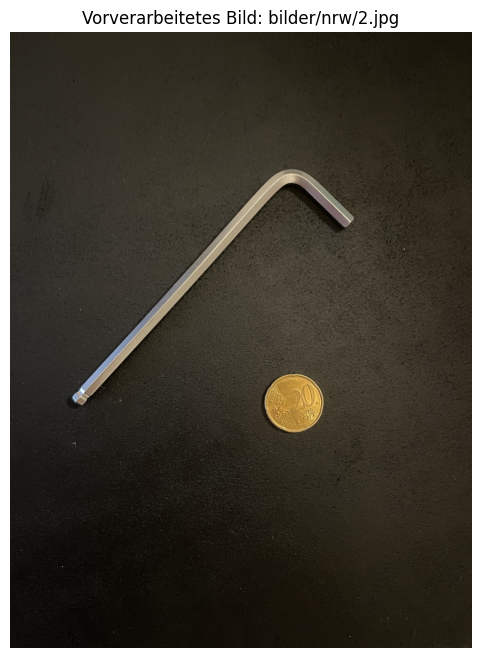

In [40]:
# ============================================================
# 1. Vorverarbeitung laden
# ============================================================
preprocessing_path = Path(PREPROCESSING_OUTPUT_PATH)
if not preprocessing_path.exists():
    raise FileNotFoundError(
        f"Vorverarbeitung nicht gefunden: {PREPROCESSING_OUTPUT_PATH}. "
        "Bitte zuerst im Notebook imbussschluessel_ausmessen.ipynb ausfuehren."
    )

with np.load(preprocessing_path) as data:
    img = data["img"]
    img_rgb = data["img_rgb"]
    gray = data["gray"]
    clean = data["clean"]
    edges = data["edges"]
    image_path = str(data["image_path"])

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title(f"Vorverarbeitetes Bild: {image_path}")
plt.axis("off")
plt.show()


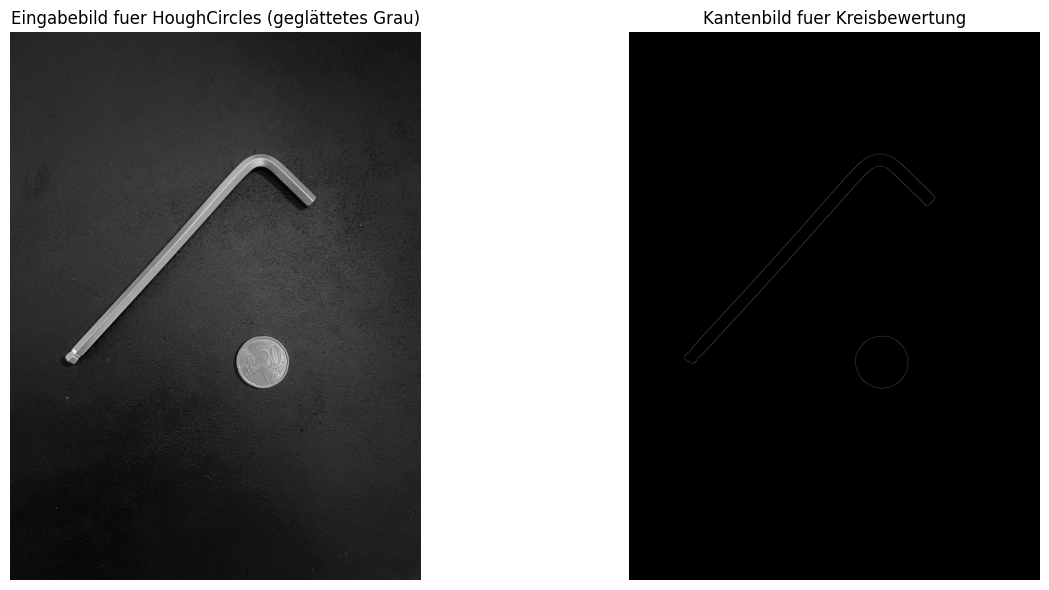

Hough-Kreis-Kandidaten nach Rundheit:
1: Mittelpunkt=(651, 2446), Radius=221px, Rundheit=0.139, Kanten=156, Fuellanteil=0.131, Score=2.84
2: Mittelpunkt=(1817, 1385), Radius=336px, Rundheit=0.125, Kanten=196, Fuellanteil=0.035, Score=0.86
3: Mittelpunkt=(619, 1803), Radius=283px, Rundheit=0.056, Kanten=45, Fuellanteil=0.038, Score=0.10
4: Mittelpunkt=(1167, 1226), Radius=262px, Rundheit=0.042, Kanten=42, Fuellanteil=0.043, Score=0.07
5: Mittelpunkt=(1298, 1990), Radius=355px, Rundheit=0.042, Kanten=48, Fuellanteil=0.033, Score=0.07
6: Mittelpunkt=(1867, 2427), Radius=179px, Rundheit=0.014, Kanten=2, Fuellanteil=1.000, Score=0.03
7: Mittelpunkt=(2405, 991), Radius=302px, Rundheit=0.028, Kanten=38, Fuellanteil=0.019, Score=0.02
8: Mittelpunkt=(1227, 2649), Radius=353px, Rundheit=0.000, Kanten=0, Fuellanteil=0.000, Score=0.00
9: Mittelpunkt=(1655, 3088), Radius=335px, Rundheit=0.000, Kanten=0, Fuellanteil=0.000, Score=0.00
10: Mittelpunkt=(2203, 1919), Radius=316px, Rundheit=0.000, Kanten

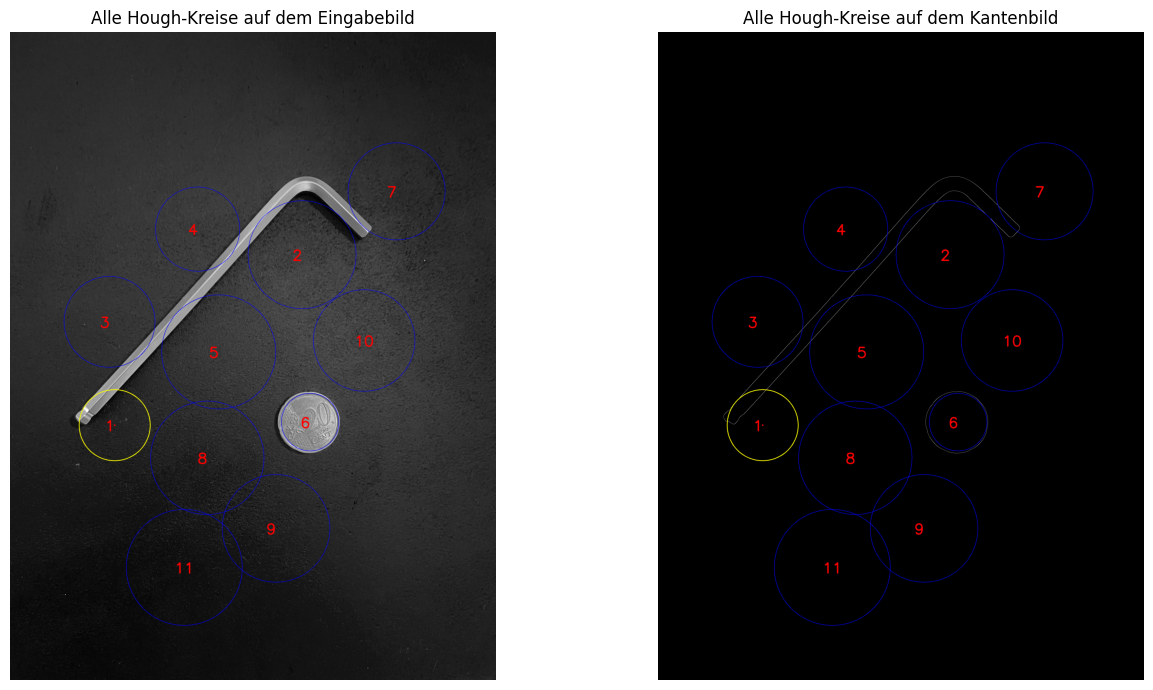

Gefundene Hough-Kreise: 11
Muenze: Mittelpunkt=(651, 2446), Radius=221px
Kanten-Support des Kreises: 156
Rundheit der Kreis-Kante: 0.139
Fuellanteil im Kreis: 0.131
Kreis-Score: 2.84
Pixel pro mm: 19.87


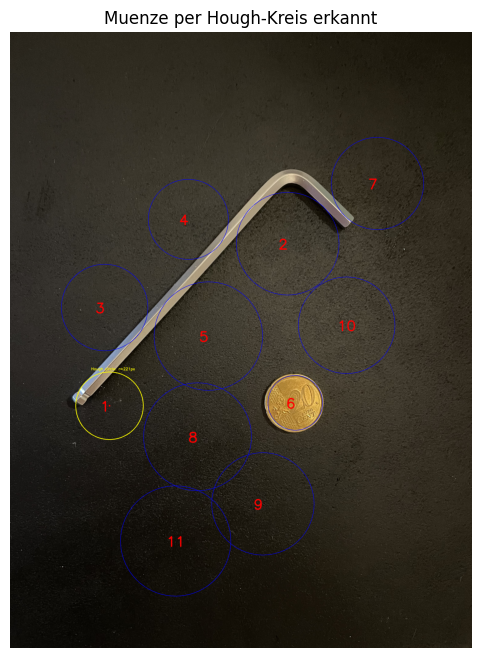

In [41]:
# ============================================================
# 2. Muenze mit Hough-Kreis-Transformation erkennen
# Ziel: Referenzmuenze als Kreis finden und Pixel/mm berechnen
# ============================================================

height, width = gray.shape[:2]
min_image_dimension = min(width, height)
min_circle_distance = int(min_image_dimension * HOUGH_CIRCLE_MIN_DIST_RATIO)
min_radius = int(min_image_dimension * HOUGH_CIRCLE_MIN_RADIUS_RATIO)
max_radius = int(min_image_dimension * HOUGH_CIRCLE_MAX_RADIUS_RATIO)

hough_input = cv2.medianBlur(gray, 5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, image, title in zip(
    axes,
    [hough_input, edges],
    [
        "Eingabebild fuer HoughCircles (geglättetes Grau)",
        "Kantenbild fuer Kreisbewertung",
    ]
):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

circles = cv2.HoughCircles(
    hough_input,
    cv2.HOUGH_GRADIENT,
    dp=HOUGH_CIRCLE_DP,
    minDist=min_circle_distance,
    param1=HOUGH_CIRCLE_PARAM1,
    param2=HOUGH_CIRCLE_PARAM2,
    minRadius=min_radius,
    maxRadius=max_radius,
)

if circles is None:
    raise RuntimeError(
        "Keine Muenze per Hough-Kreis-Transformation gefunden. "
        "Falls die Muenze sichtbar ist, HOUGH_CIRCLE_PARAM2 kleiner setzen "
        "oder den Radiusbereich anpassen."
    )

circle_candidates = np.round(circles[0]).astype(int)

def circle_edge_support(circle):
    x, y, radius = circle
    mask = np.zeros_like(edges, dtype=np.uint8)
    cv2.circle(mask, (x, y), radius, 255, 8)
    return cv2.countNonZero(cv2.bitwise_and(edges, edges, mask=mask))

def circle_edge_roundness(circle, bin_count=72):
    x, y, radius = circle
    mask = np.zeros_like(edges, dtype=np.uint8)
    cv2.circle(mask, (x, y), radius, 255, 8)
    circle_edges = cv2.bitwise_and(edges, edges, mask=mask)
    edge_y, edge_x = np.where(circle_edges > 0)

    if len(edge_x) == 0:
        return 0.0

    angles = np.arctan2(edge_y - y, edge_x - x)
    angle_bins = ((angles + np.pi) / (2 * np.pi) * bin_count).astype(int)
    angle_bins = np.clip(angle_bins, 0, bin_count - 1)
    occupied_bins = np.unique(angle_bins)
    return len(occupied_bins) / bin_count

def circle_fill_ratio(circle):
    x, y, radius = circle
    mask = np.zeros_like(clean, dtype=np.uint8)
    cv2.circle(mask, (x, y), radius, 255, -1)
    filled_pixels = cv2.countNonZero(cv2.bitwise_and(clean, clean, mask=mask))
    circle_area = np.pi * radius ** 2
    return filled_pixels / circle_area

def score_circle(circle):
    edge_support = circle_edge_support(circle)
    edge_roundness = circle_edge_roundness(circle)
    fill_ratio = circle_fill_ratio(circle)
    score = edge_roundness * edge_support * max(fill_ratio, 0.01)
    return score, edge_support, edge_roundness, fill_ratio, tuple(circle)

scored_circles = [score_circle(circle) for circle in circle_candidates]
scored_circles = sorted(scored_circles, reverse=True, key=lambda item: item[0])
best_circle_score, best_edge_support, best_edge_roundness, best_fill_ratio, (coin_x, coin_y, coin_radius) = scored_circles[0]

print("Hough-Kreis-Kandidaten nach Rundheit:")
for rank, (score, edge_support, edge_roundness, fill_ratio, (x, y, radius)) in enumerate(scored_circles, start=1):
    print(
        f"{rank}: Mittelpunkt=({x}, {y}), Radius={radius}px, "
        f"Rundheit={edge_roundness:.3f}, Kanten={edge_support}, "
        f"Fuellanteil={fill_ratio:.3f}, Score={score:.2f}"
    )

coin_center = (int(coin_x), int(coin_y))
coin_radius = int(coin_radius)
coin_diameter_px = coin_radius * 2
pixels_per_mm = coin_diameter_px / COIN_DIAMETER_MM

hough_circle_debug = cv2.cvtColor(hough_input, cv2.COLOR_GRAY2BGR)
hough_circle_edges_debug = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
coin_debug = img.copy()

for rank, (_, _, _, _, (x, y, radius)) in enumerate(scored_circles, start=1):
    center = (int(x), int(y))
    radius = int(radius)
    label_position = (center[0] - 60, center[1] + 35)

    cv2.circle(hough_circle_debug, center, radius, (255, 0, 0), 2)
    cv2.putText(hough_circle_debug, str(rank), label_position, cv2.FONT_HERSHEY_SIMPLEX, 3.0, (0, 0, 255), 8)

    cv2.circle(hough_circle_edges_debug, center, radius, (255, 0, 0), 2)
    cv2.putText(hough_circle_edges_debug, str(rank), label_position, cv2.FONT_HERSHEY_SIMPLEX, 3.0, (0, 0, 255), 8)

    cv2.circle(coin_debug, center, radius, (255, 0, 0), 2)
    cv2.putText(coin_debug, str(rank), label_position, cv2.FONT_HERSHEY_SIMPLEX, 3.0, (0, 0, 255), 8)

cv2.circle(hough_circle_debug, coin_center, coin_radius, (0, 255, 255), 4)
cv2.circle(hough_circle_debug, coin_center, 5, (0, 0, 255), -1)
cv2.circle(hough_circle_edges_debug, coin_center, coin_radius, (0, 255, 255), 4)
cv2.circle(hough_circle_edges_debug, coin_center, 5, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, image, title in zip(
    axes,
    [hough_circle_debug, hough_circle_edges_debug],
    [
        "Alle Hough-Kreise auf dem Eingabebild",
        "Alle Hough-Kreise auf dem Kantenbild",
    ]
):
    ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

cv2.circle(coin_debug, coin_center, coin_radius, (0, 255, 255), 4)
cv2.circle(coin_debug, coin_center, 5, (0, 0, 255), -1)
cv2.putText(
    coin_debug,
    f"Hough circle: r={coin_radius}px",
    (coin_center[0] - 120, coin_center[1] - coin_radius - 12),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 255, 255),
    2
)

print(f"Gefundene Hough-Kreise: {len(circle_candidates)}")
print(f"Muenze: Mittelpunkt={coin_center}, Radius={coin_radius}px")
print(f"Kanten-Support des Kreises: {best_edge_support}")
print(f"Rundheit der Kreis-Kante: {best_edge_roundness:.3f}")
print(f"Fuellanteil im Kreis: {best_fill_ratio:.3f}")
print(f"Kreis-Score: {best_circle_score:.2f}")
print(f"Pixel pro mm: {pixels_per_mm:.2f}")

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(coin_debug, cv2.COLOR_BGR2RGB))
plt.title("Muenze per Hough-Kreis erkannt")
plt.axis("off")
plt.show()


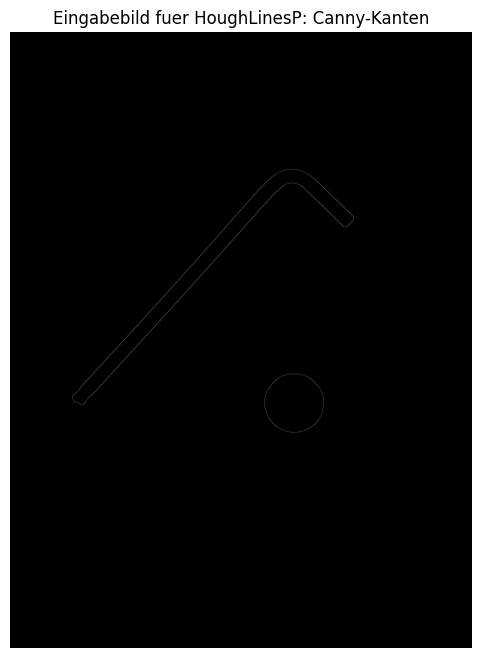

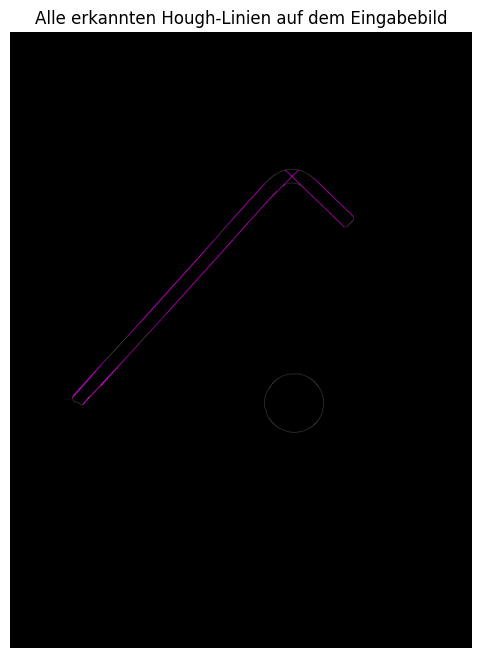

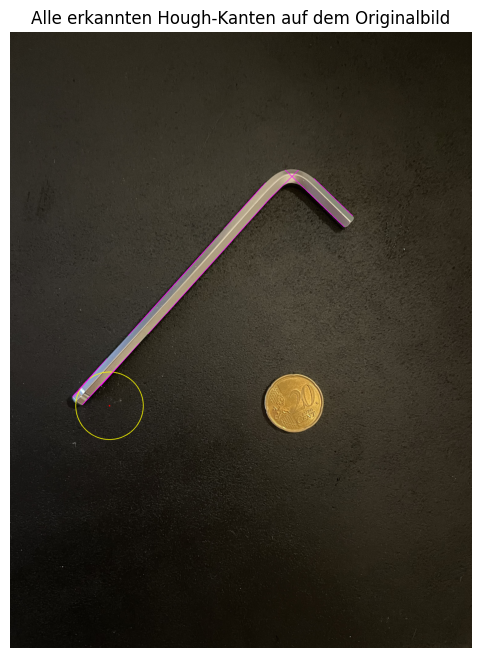

Gefundene Hough-Linien: 20
Kandidaten nach Laengenfilter: 20
Verwendete Aussenkanten: 2
Winkel zwischen den Kanten: 89.02 Grad
Abstand zwischen den Kanten: 0.00 px
Laenge des Inbus: 105.36 mm
Breite des Inbus: 26.99 mm


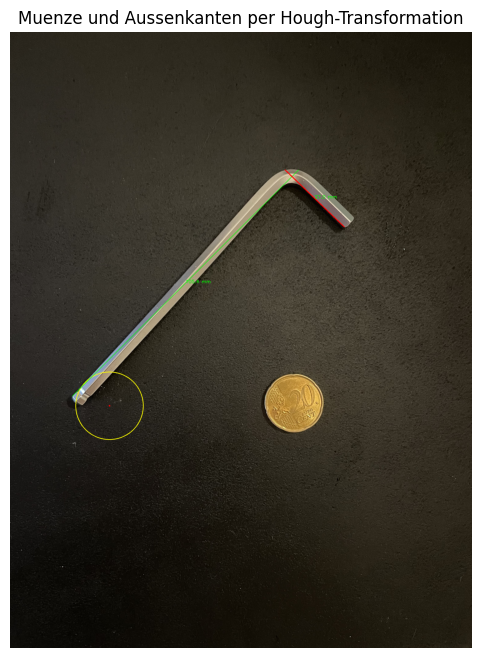

In [42]:
# ============================================================
# 3. Hough-Transformation: gerade Aussenkanten erkennen
# ============================================================

height, width = edges.shape[:2]
diagonal = np.hypot(width, height)
min_line_length = int(diagonal * HOUGH_MIN_LINE_LENGTH_RATIO)

plt.figure(figsize=(8, 8))
plt.imshow(edges, cmap="gray")
plt.title("Eingabebild fuer HoughLinesP: Canny-Kanten")
plt.axis("off")
plt.show()

lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=HOUGH_THRESHOLD,
    minLineLength=min_line_length,
    maxLineGap=HOUGH_MAX_LINE_GAP
)

hough_debug = img.copy()
cv2.circle(hough_debug, coin_center, coin_radius, (0, 255, 255), 3)
cv2.circle(hough_debug, coin_center, 5, (0, 0, 255), -1)

line_candidates = []
if lines is not None:
    for line in lines[:, 0]:
        x1, y1, x2, y2 = line
        length = np.hypot(x2 - x1, y2 - y1)
        if length < min_line_length:
            continue
        angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
        angle = ((angle + 90) % 180) - 90
        normal_angle = np.radians(angle + 90)
        midpoint_x = (x1 + x2) / 2
        midpoint_y = (y1 + y2) / 2
        offset = midpoint_x * np.cos(normal_angle) + midpoint_y * np.sin(normal_angle)
        line_candidates.append((length, angle, offset, (x1, y1, x2, y2)))

line_candidates = sorted(line_candidates, reverse=True, key=lambda item: item[0])

all_edges_input_debug = cv2.cvtColor(edges, cv2.COLOR_GRAY2BGR)
all_edges_debug = img.copy()
cv2.circle(all_edges_debug, coin_center, coin_radius, (0, 255, 255), 3)
cv2.circle(all_edges_debug, coin_center, 5, (0, 0, 255), -1)

for length, angle, offset, (x1, y1, x2, y2) in line_candidates:
    cv2.line(all_edges_input_debug, (x1, y1), (x2, y2), (255, 0, 255), 2)
    cv2.line(all_edges_debug, (x1, y1), (x2, y2), (255, 0, 255), 2)

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(all_edges_input_debug, cv2.COLOR_BGR2RGB))
plt.title("Alle erkannten Hough-Linien auf dem Eingabebild")
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(all_edges_debug, cv2.COLOR_BGR2RGB))
plt.title("Alle erkannten Hough-Kanten auf dem Originalbild")
plt.axis("off")
plt.show()

unique_lines = []
used_lines = []
for candidate in line_candidates:
    length, angle, offset, points = candidate
    same_line = any(
        abs(angle - used_angle) <= ANGLE_TOLERANCE_DEG
        and abs(offset - used_offset) <= LINE_DISTANCE_TOLERANCE_PX
        for used_angle, used_offset in used_lines
    )
    if same_line:
        continue

    unique_lines.append(candidate)
    used_lines.append((angle, offset))

def point_to_segment_distance(point, start, end):
    point = np.array(point, dtype=np.float32)
    start = np.array(start, dtype=np.float32)
    end = np.array(end, dtype=np.float32)
    segment = end - start
    segment_length_sq = np.dot(segment, segment)

    if segment_length_sq == 0:
        return np.linalg.norm(point - start)

    t = np.dot(point - start, segment) / segment_length_sq
    t = np.clip(t, 0, 1)
    projection = start + t * segment
    return np.linalg.norm(point - projection)

def segments_intersect(first_points, second_points):
    x1, y1, x2, y2 = map(float, first_points)
    x3, y3, x4, y4 = map(float, second_points)

    def orientation(ax, ay, bx, by, cx, cy):
        return (by - ay) * (cx - bx) - (bx - ax) * (cy - by)

    o1 = orientation(x1, y1, x2, y2, x3, y3)
    o2 = orientation(x1, y1, x2, y2, x4, y4)
    o3 = orientation(x3, y3, x4, y4, x1, y1)
    o4 = orientation(x3, y3, x4, y4, x2, y2)

    return o1 * o2 <= 0 and o3 * o4 <= 0

def segment_distance(first_points, second_points):
    if segments_intersect(first_points, second_points):
        return 0.0

    x1, y1, x2, y2 = first_points
    x3, y3, x4, y4 = second_points
    return min(
        point_to_segment_distance((x1, y1), (x3, y3), (x4, y4)),
        point_to_segment_distance((x2, y2), (x3, y3), (x4, y4)),
        point_to_segment_distance((x3, y3), (x1, y1), (x2, y2)),
        point_to_segment_distance((x4, y4), (x1, y1), (x2, y2)),
    )

def angle_distance(first_angle, second_angle):
    difference = abs(first_angle - second_angle)
    return min(difference, 180 - difference)

def extend_line_with_candidates(base_line, candidates):
    _, base_angle, base_offset, base_points = base_line
    angle_rad = np.radians(base_angle)
    direction = np.array([np.cos(angle_rad), np.sin(angle_rad)], dtype=np.float32)
    normal = np.array([-np.sin(angle_rad), np.cos(angle_rad)], dtype=np.float32)
    projected_points = []

    for candidate in candidates:
        _, angle, offset, (x1, y1, x2, y2) = candidate
        if angle_distance(base_angle, angle) > EXTEND_LINE_ANGLE_TOLERANCE_DEG:
            continue
        if abs(base_offset - offset) > EXTEND_LINE_DISTANCE_TOLERANCE_PX:
            continue

        projected_points.append(np.dot(np.array([x1, y1], dtype=np.float32), direction))
        projected_points.append(np.dot(np.array([x2, y2], dtype=np.float32), direction))

    if len(projected_points) < 2:
        return base_line

    start_t = min(projected_points)
    end_t = max(projected_points)
    start_point = direction * start_t + normal * base_offset
    end_point = direction * end_t + normal * base_offset
    x1, y1 = np.round(start_point).astype(int)
    x2, y2 = np.round(end_point).astype(int)
    extended_length = np.hypot(x2 - x1, y2 - y1)

    return (extended_length, base_angle, base_offset, (x1, y1, x2, y2))

best_pair = None
best_score = None
best_pair_distance = None
for i, first in enumerate(line_candidates):
    for second in line_candidates[i + 1:]:
        angle_difference = abs(first[1] - second[1])
        angle_difference = min(angle_difference, 180 - angle_difference)
        right_angle_error = abs(angle_difference - 90)

        if right_angle_error > RIGHT_ANGLE_TOLERANCE_DEG:
            continue

        pair_distance = segment_distance(first[3], second[3])
        if pair_distance > MAX_RIGHT_ANGLE_DISTANCE_PX:
            continue

        length_sum = first[0] + second[0]
        score = (pair_distance, right_angle_error, -length_sum)
        if best_score is None or score < best_score:
            best_score = score
            best_pair = (first, second)
            best_pair_distance = pair_distance

if best_pair is None:
    raise RuntimeError("Kein nahes Linienpaar mit ca. 90 Grad gefunden")

outer_edges = [
    extend_line_with_candidates(best_pair[0], line_candidates),
    extend_line_with_candidates(best_pair[1], line_candidates),
]

measurements = []

for length, angle, offset, (x1, y1, x2, y2) in outer_edges:
    length_mm = length / pixels_per_mm
    measurements.append((length, length_mm, angle, offset, (x1, y1, x2, y2)))
    label_position = ((x1 + x2) // 2, (y1 + y2) // 2)
    cv2.line(hough_debug, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(
        hough_debug,
        f"{length_mm:.1f} mm",
        label_position,
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,
        (0, 255, 0),
        2
    )

if outer_edges:
    _, _, _, (x1, y1, x2, y2) = outer_edges[0]
    cv2.line(hough_debug, (x1, y1), (x2, y2), (0, 0, 255), 5)

if len(measurements) < 2:
    raise RuntimeError("Zu wenige Aussenkanten fuer Laenge/Breite erkannt")

measurements = sorted(measurements, reverse=True, key=lambda item: item[0])
inbus_length_mm = measurements[0][1]

angle_difference = abs(measurements[0][2] - measurements[1][2])
angle_difference = min(angle_difference, 180 - angle_difference)
if angle_difference <= ANGLE_TOLERANCE_DEG:
    inbus_width_px = abs(measurements[0][3] - measurements[1][3])
    inbus_width_mm = inbus_width_px / pixels_per_mm
else:
    inbus_width_mm = measurements[1][1]

print(f"Gefundene Hough-Linien: {0 if lines is None else len(lines)}")
print(f"Kandidaten nach Laengenfilter: {len(line_candidates)}")
print(f"Verwendete Aussenkanten: {len(outer_edges)}")
print(f"Winkel zwischen den Kanten: {angle_difference:.2f} Grad")
print(f"Abstand zwischen den Kanten: {best_pair_distance:.2f} px")
print(f"Laenge des Inbus: {inbus_length_mm:.2f} mm")
print(f"Breite des Inbus: {inbus_width_mm:.2f} mm")

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(hough_debug, cv2.COLOR_BGR2RGB))
plt.title("Muenze und Aussenkanten per Hough-Transformation")
plt.axis("off")
plt.show()
